#### Getting door and hole areas

In [14]:
from pathlib import Path

from cubes.construct.utilities import (
    ModifiedIDF as IDF,
)

EPLUS_PATH = "/usr/local/EnergyPlus-9-5-0/"

# Set IDD path
IDF.setiddname(str(Path(EPLUS_PATH) / "Energy+.idd"))

idf = IDF("/workspaces/CUBES/beizaee_validation/building_model_full_afn.idf")

doors = {}
for sf in idf.idfobjects["FENESTRATIONSURFACE:DETAILED"]:
    if "door" in sf.Name.lower():
        doors[sf.Name] = sf.area

holes = {}
for sf in idf.idfobjects["FENESTRATIONSURFACE:DETAILED"]:
    if "hole" in sf.Name.lower():
        holes[sf.Name] = sf.area


In [16]:
doors

{'kitchen_Wall_4_0_0_0_0_0_Door': np.float64(2.1999999999999997),
 'kitchen_Partition_5_0_0_0_0_0_Door': np.float64(2.1999999999999993),
 'hall_downstairs_Partition_3_0_0_0_0_0_Door_10015': np.float64(2.1999999999999997),
 'backroom_Partition_5_0_0_0_0_0_Door': np.float64(1.4700000000000006),
 'hall_downstairs_Partition_2_0_0_0_0_0_Door_10019': np.float64(1.4700000000000006),
 'hall_downstairs_Wall_5_0_0_0_0_0_Door': np.float64(2.1999999999999997),
 'hall_downstairs_Partition_6_0_0_0_0_0_Door': np.float64(2.2),
 'front_room_Partition_4_0_0_0_0_0_Door_10033': np.float64(2.2),
 'bathroom_Partition_6_0_0_0_0_0_Door': np.float64(1.81183619795976),
 'hall_upstairs_Partition_3_0_0_0_0_0_Door_10040': np.float64(1.8118361979597597),
 'bedroom_1_Partition_5_0_0_0_0_0_Door': np.float64(2.1999999999999975),
 'hall_upstairs_Partition_2_0_0_0_0_0_Door_10042': np.float64(2.1999999999999975),
 'hall_upstairs_Partition_4_0_0_0_0_0_Door': np.float64(1.4625737889876786),
 'wash_closet_Partition_2_0_0_0_

In [15]:
holes

{'hall_downstairs_Ceiling_1_0_6_0_6_0_Hole': np.float64(1.966980228796134),
 'hall_upstairs_Floor_0_0_0_0_0_0_Hole_10029': np.float64(1.9669802287961342)}


#### Testing the build function

In [1]:

import pandas as pd
from cubes.construct.buildingconfig import load_building_config
from cubes.construct.building import Building
from cubes.package.envconfig import EnvConfig


files_dir = "/workspaces/CUBES/beizaee_validation/misc/input"
bc_file_path = "/workspaces/CUBES/cubes/data/buildingconfigs/thermostat_experiment/2023/case0.json"

materials = pd.read_pickle("/workspaces/CUBES/cubes/materials.pickle")
windows = pd.read_pickle("/workspaces/CUBES/cubes/windows.pickle")

BC = load_building_config(bc_file_path, files_dir=files_dir)
EC = EnvConfig(files_dir=files_dir)
building=Building(BC,materials,windows)
#building=Building(BC,materials_evaluator(),windows_evaluator())
building.build()
idf = building.get_idf()


<jemalloc>: MADV_DONTNEED does not work (memset will be used instead)
<jemalloc>: (This is the expected behaviour if you are running under QEMU)
/workspaces/CUBES/cubes/construct/utilities.py:68: RuntimeWarning: invalid value encountered in divide
  return n / np.linalg.norm(n)


Added opening between front_room and hall_downstairs (vertical, 2.20 m²)
Added opening between front_room and backroom (vertical, 2.20 m²)
Added opening between front_room and kitchen (vertical, 1.97 m²)
Added opening between kitchen and hall_downstairs (vertical, 2.20 m²)
Added opening between backroom and kitchen (vertical, 2.20 m²)
Added opening between bedroom_3 and hall_upstairs (vertical, 2.20 m²)
Added opening between bedroom_1 and hall_upstairs (vertical, 2.20 m²)
Added opening between bathroom and hall_upstairs (vertical, 2.20 m²)
Added opening between bedroom_2 and hall_upstairs (vertical, 2.20 m²)
Added opening between hall_downstairs and hall_upstairs (horizontal, 1.88 m²)
🗓️ Added AlwaysOnSchedule.
🗓️ Added AlwaysOffSchedule.
🗑️ Removed old infiltration, ventilation, and mixing objects.
🔧 AFN controls set up.
🔵 Internal Door & Hole Openings Created: 10
🔵 External Surfaces with Cracks: 21
🔵 External Fenestrations with Cracks: 8
🔵 User-defined openings created: 10


/usr/local/lib/python3.9/dist-packages/eppy/geometry/surface.py:63: RuntimeWarning: invalid value encountered in scalar divide
  mag = (x_val / magnitude, y_val / magnitude, z_val / magnitude)


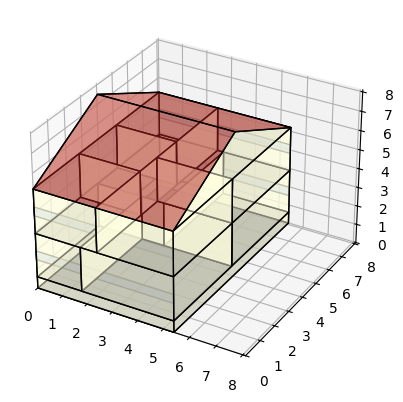

In [2]:
idf.view_model()

In [3]:
# idf.translate([0, 0, 15])

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def edges_from_coords(coords):
    """Return sorted edges for a surface given its coords."""
    edges = []
    for i in range(len(coords)):
        p1 = tuple(np.round(coords[i], 6))  # rounding for numerical stability
        p2 = tuple(np.round(coords[(i + 1) % len(coords)], 6))
        edges.append(tuple(sorted((p1, p2))))
    return edges

def find_problem_surfaces(idf):
    """Find surfaces with edges shared by >2 or by no other surfaces."""
    edge_map = {}
    for sf in idf.idfobjects["BUILDINGSURFACE:DETAILED"]:
        for edge in edges_from_coords(sf.coords):
            edge_map.setdefault(edge, []).append(sf.Name)

    problem_surfaces = set()
    for edge, surfaces in edge_map.items():
        if len(surfaces) > 2:
            problem_surfaces.update(surfaces)
        # edge only used by 1 surface, but is not ground or outdoors
        elif len(surfaces) == 1:
            sf = next(s for s in idf.idfobjects["BUILDINGSURFACE:DETAILED"] if s.Name == surfaces[0])
            if sf.Outside_Boundary_Condition.lower() == "surface":
                problem_surfaces.add(sf.Name)

    return list(problem_surfaces)

def plot_surfaces_3d(idf, surface_names):
    """Plot given surfaces in 3D for debugging."""
    surfaces = [sf for sf in idf.idfobjects["BUILDINGSURFACE:DETAILED"] if sf.Name in surface_names]
    if not surfaces:
        print("⚠️ No surfaces to plot.")
        return

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    for sf in surfaces:
        verts = [sf.coords]
        poly = Poly3DCollection(verts, alpha=0.6)
        ax.add_collection3d(poly)
        centroid = tuple(sum(c[j] for c in sf.coords) / len(sf.coords) for j in range(3))
        ax.text(*centroid, sf.Name, fontsize=8)

    # auto scale
    all_points = [pt for sf in surfaces for pt in sf.coords]
    xs, ys, zs = zip(*all_points)
    ax.set_xlim(min(xs), max(xs))
    ax.set_ylim(min(ys), max(ys))
    ax.set_zlim(min(zs), max(zs))
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_zlabel('Z (m)')
    plt.title("Problem Surfaces")
    plt.show()


Problem surfaces: ['storey 2 Subfloor ceiling_3', 'Block bedroom_1 Storey 0 Wall 0003_2', 'storey 2 hall_upstairs ceiling_1', 'Block Loft_1 Storey 0 Floor 0001_1', 'Block kitchen Storey 0 Wall 0003', 'Block Loft_0 Storey 0 Floor 0001_1', 'Block bedroom_1 Storey 0 Floor 0001_1', 'Block backroom Storey 0 Roof 0001_1', 'Block backroom Storey 0 Wall 0004_1', 'Block kitchen Storey 0 Wall 0002', 'Block bedroom_2 Storey 0 Wall 0003_2', 'Block bedroom_1 Storey 0 Wall 0001', 'Block bathroom Storey 0 Floor 0001_1', 'storey 2 Subfloor ceiling_2', 'Block bathroom Storey 0 Wall 0003', 'Block hall_downstairs Storey 0 Floor 0001_1', 'Block bedroom_2 Storey 0 Floor 0001_2', 'Block bedroom_1 Storey 0 Wall 0002_1', 'Block front_room Storey 0 Wall 0004', 'Block hall_upstairs Storey 0 Floor 0001_3', 'Block hall_downstairs Storey 0 Wall 0002_1', 'Block backroom Storey 0 Wall 0002', 'Block bedroom_3 Storey 0 Wall 0003', 'Block hall_downstairs Storey 0 Roof 0001_2', 'Block Loft_2 Storey 0 Floor 0001_1', 'Blo

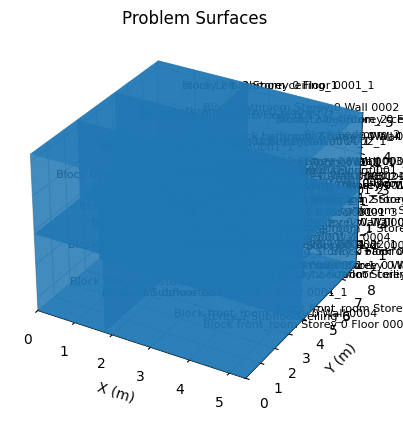

In [5]:
problems = find_problem_surfaces(idf)
print("Problem surfaces:", problems)

plot_surfaces_3d(idf, problems)


In [6]:
import matplotlib.pyplot as plt

def plot_idf_surfaces(idf, surface_names, colors=None, show_labels=True):
    """
    Plot selected IDF surfaces in 2D (top-down XY projection).

    Args:
        idf: The IDF object.
        surface_names (list[str]): List of surface names to plot.
        colors (list[str], optional): List of matplotlib colors to use.
                                      Defaults to auto color cycle.
        show_labels (bool): Whether to label surfaces by name.
    """
    surfaces = [
        sf for sf in idf.idfobjects["BUILDINGSURFACE:DETAILED"]
        if sf.Name in surface_names
    ]

    if colors is None:
        colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

    plt.figure()
    for i, sf in enumerate(surfaces):
        coords = sf.coords + [sf.coords[0]]  # close the polygon
        xs, ys, zs = zip(*coords)
        plt.plot(xs, ys, color=colors[i % len(colors)], label=sf.Name)
        if show_labels:
            plt.text(sum(xs)/len(xs), sum(ys)/len(ys), sf.Name, fontsize=8)

    plt.axis('equal')
    plt.xlabel("X (m)")
    plt.ylabel("Y (m)")
    plt.title("Selected IDF Surfaces")
    plt.legend()
    plt.show()


In [7]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def plot_idf_surfaces_3d(idf, surface_names, colors=None, show_labels=True):
    """
    Plot selected IDF surfaces in 3D.

    Args:
        idf: The IDF object.
        surface_names (list[str]): List of surface names to plot.
        colors (list[str], optional): Colors for each surface.
        show_labels (bool): Whether to show labels at centroid.
    """
    surfaces = [
        sf for sf in idf.idfobjects["BUILDINGSURFACE:DETAILED"]
        if sf.Name in surface_names
    ]
    if not surfaces:
        print("⚠️ No surfaces found with given names.")
        return

    if colors is None:
        colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    for i, sf in enumerate(surfaces):
        coords = sf.coords  # list of (x, y, z)
        verts = [coords]
        poly = Poly3DCollection(verts, alpha=0.6, facecolor=colors[i % len(colors)])
        ax.add_collection3d(poly)

        if show_labels:
            centroid = tuple(sum(c[j] for c in coords) / len(coords) for j in range(3))
            ax.text(*centroid, sf.Name, fontsize=8)

    # Auto scale axes
    all_points = [pt for sf in surfaces for pt in sf.coords]
    xs, ys, zs = zip(*all_points)
    ax.set_xlim(min(xs), max(xs))
    ax.set_ylim(min(ys), max(ys))
    ax.set_zlim(min(zs), max(zs))

    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_zlabel('Z (m)')
    plt.title("3D IDF Surfaces")
    plt.show()


/tmp/ipykernel_13396/3063611723.py:42: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(min(ys), max(ys))


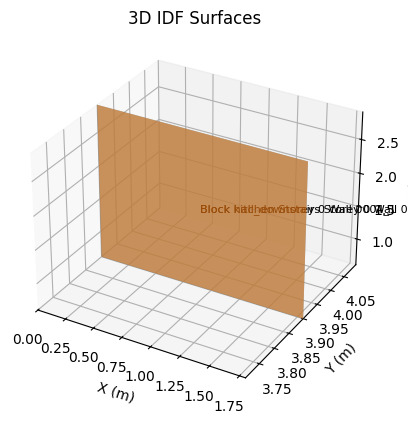

In [8]:
plot_idf_surfaces_3d(idf, [
    "Block hall_downstairs Storey 0 Wall 0002_1",
    "Block kitchen Storey 0 Wall 0004_1"
])


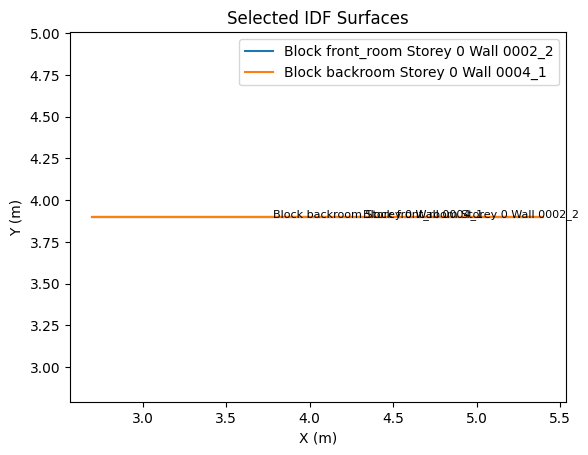

In [9]:
plot_idf_surfaces(idf, ["Block front_room Storey 0 Wall 0002_2",
                        "Block backroom Storey 0 Wall 0004_1"])


In [10]:
idf.save("test.idf")

In [11]:
doors = {}
for sf in idf.idfobjects["FENESTRATIONSURFACE:DETAILED"]:
    if "door" in sf.Name.lower():
        doors[sf.Name] = sf.area

holes = {}
for sf in idf.idfobjects["FENESTRATIONSURFACE:DETAILED"]:
    if "hole" in sf.Name.lower():
        holes[sf.Name] = sf.area


In [12]:
holes

{'Block hall_downstairs Storey 0 Roof 0001_1_hole': np.float64(1.8809999999646112),
 'Block hall_upstairs Storey 0 Floor 0001_1_hole': np.float64(1.880999999964611)}

In [ ]:
import os
from pathlib import Path
from eppy import modeleditor
from eppy.modeleditor import IDF

# Define EnergyPlus installation path
EPLUS_PATH = "/usr/local/EnergyPlus-9-5-0/"  # Update if needed

# Set the IDD file path
iddfile = os.path.join(EPLUS_PATH, "Energy+.idd")
IDF.setiddname(iddfile)  # Load the IDD file

idf_file = "/workspaces/CUBES/beizaee_validation/test.idf"

# Define the weather file path
weather_file_path = "/workspaces/CUBES/cubes/data/weather/loughborough.epw"

# ✅ Initialize IDF with both the IDF file and Weather file
idf = IDF(idf_file, weather_file_path)

# Print IDF summary
print("IDF Version:", idf.idfobjects["VERSION"])
print("Number of objects:", len(idf.idfobjects))

# Define the test function to run the simulation
def test_idf(idf):
    # Define paths for saving and output
    cwd_path = os.getcwd()
    env_data_path = os.path.join(cwd_path, "input_case_1")
    Path(env_data_path).mkdir(parents=True, exist_ok=True)

    # Save the modified IDF
    idf.save(filename=os.path.join(env_data_path, "test1.idf"))

    # Define output directory
    output_directory = os.path.join(env_data_path, "output/")
    Path(output_directory).mkdir(parents=True, exist_ok=True)

    # ✅ Run EnergyPlus simulation (No need to pass weather file separately now)
    idf.run(output_directory=output_directory)

# Run the test function
test_idf(idf)


IDF Version: [
Version,
    9.5;                      !- Version Identifier
]
Number of objects: 821

/usr/local/EnergyPlus-9-5-0/energyplus --weather /workspaces/CUBES/cubes/data/weather/loughborough.epw --output-directory /workspaces/CUBES/beizaee_validation/input_case_1/output --idd /usr/local/EnergyPlus-9-5-0/Energy+.idd /workspaces/CUBES/beizaee_validation/in.idf

EnergyPlus Starting
EnergyPlus, Version 9.5.0-de239b2e5f, YMD=2025.08.05 23:11
Initializing Response Factors
Calculating CTFs for "WALL-CONSTRUCTION"
Calculating CTFs for "WALL-CONSTRUCTION"
Calculating CTFs for "ROOF-CONSTRUCTION"
Calculating CTFs for "GROUNDFLOOR-CONSTRUCTION"
Calculating CTFs for "FLOOR-CONSTRUCTION"
Calculating CTFs for "INTERNALWALL-CONSTRUCTION"
Calculating CTFs for "PARTITIONDOOR-CONSTRUCTION"
Calculating CTFs for "FURNITURE-CONSTRUCTION"
Calculating CTFs for "LAST FLOOR-CONSTRUCTION"
Calculating CTFs for "LAST FLOOR-CONSTRUCTION"
Calculating CTFs for "SUBFLOOR-CONSTRUCTION"
Initializing Window Op

#### Adding new materials to pickle

In [ ]:
import pickle
import pandas as pd
from cubes.construct.material import Material, InfraredTransparentMaterial
materials = pd.read_pickle("/workspaces/CUBES/cubes/materials.pickle")

door_material = Material(
    name="Door_WoodSolid_test_35mm",   # new clear name
    rho=700.0,                    # Density [kg/m3]
    cp=2390.0,                    # Specific Heat [J/kg-K]
    k=0.19,                       # Conductivity [W/m-K]
    roughness="Rough",            # Surface roughness
    thermal_absorptance=0.9,
    solar_absorptance=0.5,
    visual_absorptance=0.5
)

# Then add it to your materials dict
materials["Door_WoodSolid_35mm"] = door_material

materials["IRTMaterial"] = InfraredTransparentMaterial(name="IRTMaterial")


# Save to pickle file
path = "/workspaces/CUBES/cubes/materials.pickle"
with open(path, "wb") as f:
    pickle.dump(materials, f)

